In [2]:
import pandas as pd

In [3]:
url = "https://raw.githubusercontent.com/pandas-dev/pandas/main/doc/data/titanic.csv"
df = pd.read_csv(url)

############################################################################################################################################################################################

<h1 style="text-align:center;"> TITANIC SURVIVAL ANALYSIS </h1>

<h2 style="text-align:center;">(Using Python Pandas and Jupyter Notebook)</h2>

############################################################################################################################################################################################

### Problem Statement

The Titanic disaster is one of the most well-known historical tragedies. The project aims to analyze the passenger data to understand what all factors have influenced the survival rates. The goal is to identify the patterns and relationships between the passenger characteristics such as the gender, age, class, and fare, and determine and interpret how these factors affected the survival outcomes. This analysis will be useful for understanding how the socio-economic and demographic factors can influence the decision making and survival of any person in the real-world scenario.

############################################################################################################################################################################################

### INTRODUCTION:

This project aims to analyze and interpret the Titanic passenger dataset to understand what are the different factors that may have affected survival during the tragic 1912 Titanic disaster. The RMS Titanic was a British passenger liner deemed "practically unsinkable," which sank on its maiden voyage after striking an iceberg on April 14, 1912. I will be using Python Pandas for studying and identifying different patterns which are related to the gender, age, family size, passenger class and fare. I will be using data analysis and visualizations techniques to identify which passengers characteristics were most strongly connected to survival. 

############################################################################################################################################################################################

### DATASET DESCRIPTION:


The dataset used for the project is the Survival dataset from the tragic sinking of RMS Titanic in 1912 which contains about 891 Titanic passengers and 12 columns. The important columns included are Survived, Pclass, Name, Sex, Age, SibSp, Parch, Fare, Cabin and Embarked. The passengers that did not survive use the 0 in the column, whereas the passengers who did survive represents 1. The df.info() output shows the data types of each column and highlights missing values in columns such as Age, Cabin, and Embarked. The summary statistics provide insights into numerical features like age and fare, including their mean, minimum, and maximum values. This dataset is relevant to the problem because it contains detailed passenger information that allows us to analyze survival patterns based on demographic and socio-economic factors.

In [4]:
df.shape

(891, 12)

In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


############################################################################################################################################################################################

### QUESTIONS:

1. What percentage of passengers survived?
2. Did gender affect survival?
3. Did passenger class affect survival?
4. Did age affect survival?
5. Did fare price affect survival?
6. Did family size affect survival?
7. Which embarkation port had the highest survival rate?
8. What are the main insights from the analysis?

############################################################################################################################################################################################

### DATA CLEANING AND PREPROCESSING

After I had loaded the dataset, I checked the dataset for any missing values or inconsistencies that could modify or make the data visualization. After checking, I identified that Age, Cabin, and Embarked columns contains the most missing values. 
For preparing the cleaned and preprocessed dataset for analysis:

- The missing values from Age were filled using the median
- The missing values in Embarked were filled using the most frequent value
- The cabin column was removed completely due to a large number of missing values. 

After this, I can confirm the dataset is clean and suitable, ready fro analysis. 

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

FROM THE ABOVE, WE CAN UNDERSTAND IT NEEDS CLEANING

In [10]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [11]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [12]:
df = df.drop(columns=["Cabin"])

TO VERIFY IT WORKED:

In [13]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

############################################################################################################################################################################################

### ANALYSIS AND RESULTS (COMBINING EDA AND QUESTIONS)

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------

1. What percentage of passengers survived?

In [14]:
survival_rate = df["Survived"].mean() * 100
survival_rate
round(survival_rate, 2)

np.float64(38.38)

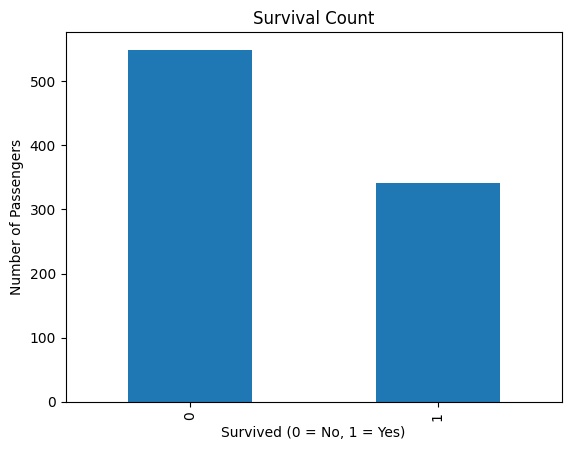

In [15]:
import matplotlib.pyplot as plt

df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

Approximately around 38.38% of the passengers had survived the Titanic disaster. The bar chart above represents that more passengers did not survive compared to those who had survived. 

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------

2. Did gender affect survival?


In [16]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

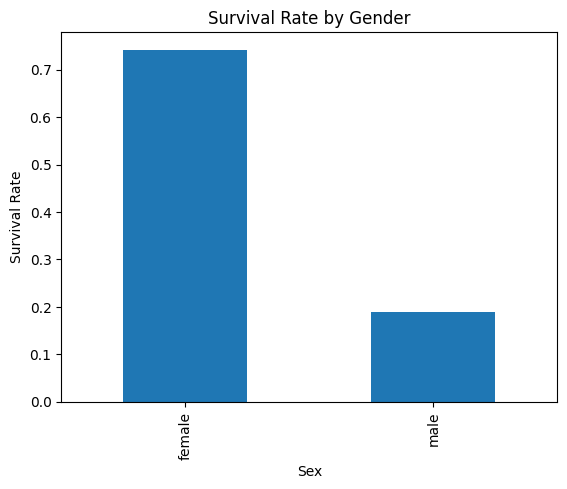

In [17]:
df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

The analysis shows that female passengers had a significantly higher survival rate compared to male passengers. We can see that the difference between both is around 0.5, which indicates that gender played a major role in determining survival during the Titanic disaster.

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------

3. Did passenger class affect survival?

In [18]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

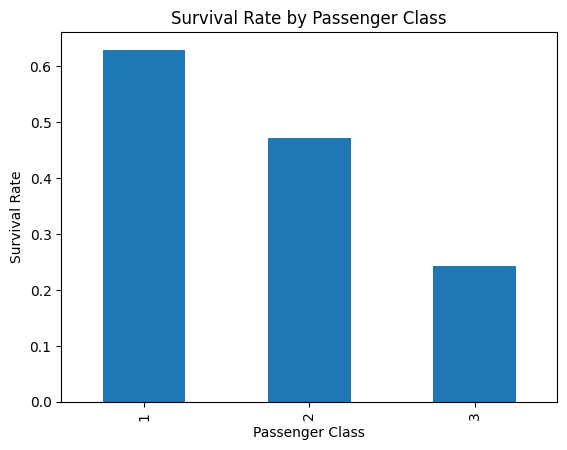

In [19]:
df.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.xlabel("Passenger Class")
plt.show()

The analysis shows that passengers in higher classes had a better chance of survival. First-class passengers had the highest survival rate, while third-class passengers had the lowest. This suggests that passenger class played a significant role in survival.

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------

4. Did age affect survival?

In [20]:
df["Age_Group"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                        labels=["Child", "Teen", "Young Adult", "Adult", "Senior"])

In [21]:
round(df.groupby("Age_Group")["Survived"].mean() * 100, 2)

Age_Group
Child          57.97
Teen           42.86
Young Adult    35.33
Adult          40.00
Senior         22.73
Name: Survived, dtype: float64

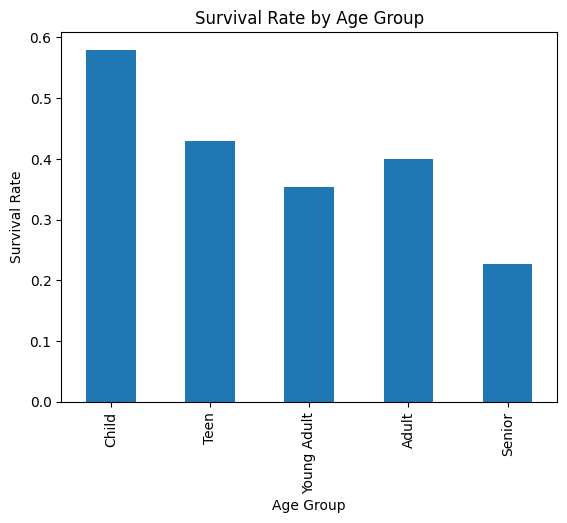

In [22]:
df.groupby("Age_Group")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Age Group")
plt.ylabel("Survival Rate")
plt.xlabel("Age Group")
plt.show()

The above representation shows that the survival rates are varrying across multiple different age groups. The younger children had a higher survival rate compared to the adults and older passengers who had comparatively lower survival rates. We can observe that the age did play a huge role in survival during the Titanic disaster, making an assumption that they decided to save the younger ones first. 

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------

5. Did fare price affect survival?

In [23]:
df.groupby("Survived")["Fare"].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

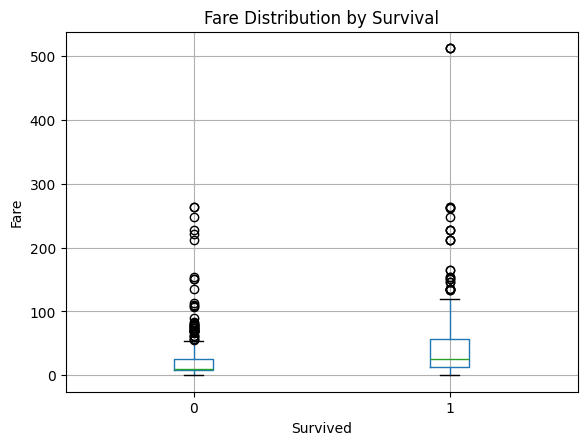

In [24]:
df.boxplot(column="Fare", by="Survived")
plt.title("Fare Distribution by Survival")
plt.suptitle("")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

Passengers that survived consisted mainly of the passengers who paid higher fares compared to the ones who paid lesser ones. This could be identified as that the wealthier and richer people had a better chance of survival compared to the middle class and poor people. 

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------

6. Did family size affect survival?

In [25]:
df["Family_Size"] = df["SibSp"] + df["Parch"]

round(df.groupby("Family_Size")["Survived"].mean() * 100, 2)

Family_Size
0     30.35
1     55.28
2     57.84
3     72.41
4     20.00
5     13.64
6     33.33
7      0.00
10     0.00
Name: Survived, dtype: float64

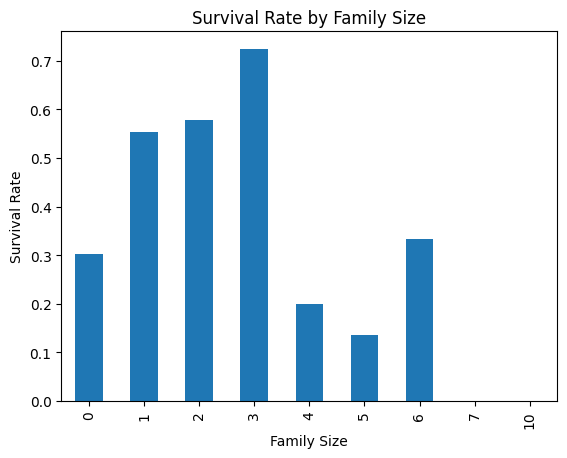

In [26]:
df.groupby("Family_Size")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Family Size")
plt.ylabel("Survival Rate")
plt.xlabel("Family Size")
plt.show()

From the representation above, we can identify that the families with a size of 3 survived most compared to the other ones. It can be analyzed that lower the size of the family means higher survival rates compared to those traveling alone or in very large groups. This can be identified as a factor where family size influenced the survival chance. 

---------------------------------------------------------------------------------------------------------------------------------------------------------------------------

7. Which embarkation port had the highest survival rate?

In [27]:
round(df.groupby("Embarked")["Survived"].mean() * 100, 2)

Embarked
C    55.36
Q    38.96
S    33.90
Name: Survived, dtype: float64

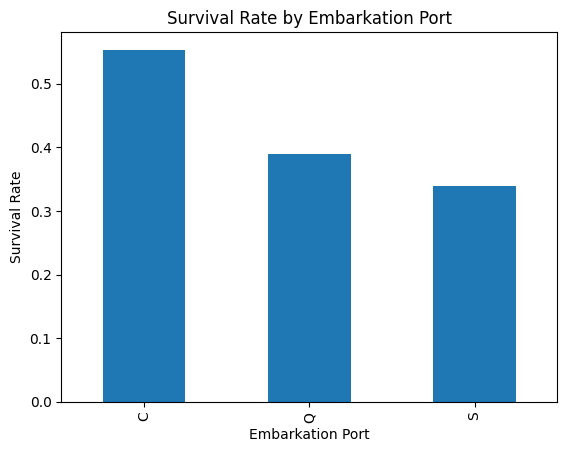

In [28]:
df.groupby("Embarked")["Survived"].mean().plot(kind="bar")
plt.title("Survival Rate by Embarkation Port")
plt.ylabel("Survival Rate")
plt.xlabel("Embarkation Port")
plt.show()

As we can see from the graph above, Cherbourg (C) has the highest survival rate. Henceforth, passengers who boarded from certain ports had higher survival rates compared to others. 
This indicates that embarkation location may have influenced survival outcomes.



---------------------------------------------------------------------------------------------------------------------------------------------------------------------------

8. What are the main insights from the analysis?

The analysis of the Titanic dataset reveals several important insights we interpreted from the above questions and visualization methods that can narrow down the factors and different pointers that influence the survival rates for the tragic disaster. 

- Gender had the strongest impact on survival, with females having much higher survival rates.
- First-class passengers had significantly better survival chances compared to lower classes.
- Higher fares were associated with higher survival, indicating socio-economic influence.
- Smaller families had better survival rates compared to large groups.
- Embarkation location also influenced survival patterns.

These findings show that survival was not random, but strongly influenced by social and economic factors.
Overall, factors such as gender, class, age, and socio-economic status played a major role in determining survival during the Titanic disaster.

############################################################################################################################################################################################

### CONCLUSION

In conclusion, gender, passenger class, age, and fare all had a substantial impact on the survival outcomes of the passengers according to the Titanic dataset analysis that has been completeed. Mostly, better survival rates were linked to smaller family sizes and those who had purchased higher fares for the journey. The survival percentages were also high for first class passengers and those who were female passengers. 
Overall, we can conclude that the socioeconomic and demographic characteristics had a significant impact on the survival during the Titanic accident which took place in 1912. 

############################################################################################################################################

### SUMMARY

This project successfully used Python Pandas to analyze the Titanic dataset. Through data cleaning, exploratory analysis, and visualization, meaningful insights were extracted about survival patterns.

The results demonstrate how data analysis can be used to uncover real-world patterns and support decision-making.

############################################################################################################################################